# Egyptian **Dataset**

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split,RepeatedStratifiedKFold, KFold, cross_val_score

from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
!pip install transformers
!pip install nlpaug
import transformers
from transformers import AutoModel, BertTokenizerFast, AutoModelForSequenceClassification, Trainer, TrainingArguments

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 18.5 MB/s eta 0:00:00


In [2]:
from google.colab import files
import io
uploaded =files.upload()

Saving Egyptian dataset.xlsx to Egyptian dataset.xlsx


In [3]:
df = pd.read_excel(io.BytesIO(uploaded['Egyptian dataset.xlsx']))
df.head()

,commentaire,classe
0,مبروك و سامحونا لعجزنا التام. عقبال اللي جوه. ...,normal
1,كلنا بره ومش هنبطل نزايد على العجايز الي جابون...,hate
2,بدل ما انت قاعد بره كده تعالي ازرع الصحرا,normal
3,قذر اتفووو ماتيجى مصر وتورينا نفسك كدا ياجبان,hate
4,وهكذا رجال الشو اللي محرومين من عمل برنامج الغ...,hate


In [4]:
df['classe'].value_counts()

,count
classe,
normal,453
hate,444
abusive,203


<Axes: title={'center': 'Classe Distribution'}, xlabel='classe'>

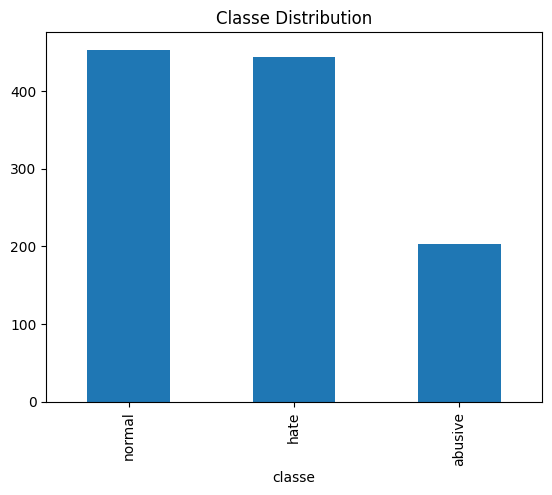

In [5]:
df.classe.value_counts().plot.bar(x=df.classe.unique(), title='Classe Distribution')

In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Label']=le.fit_transform(df['classe'])
df.head(6)

,commentaire,classe,Label
0,مبروك و سامحونا لعجزنا التام. عقبال اللي جوه. ...,normal,2
1,كلنا بره ومش هنبطل نزايد على العجايز الي جابون...,hate,1
2,بدل ما انت قاعد بره كده تعالي ازرع الصحرا,normal,2
3,قذر اتفووو ماتيجى مصر وتورينا نفسك كدا ياجبان,hate,1
4,وهكذا رجال الشو اللي محرومين من عمل برنامج الغ...,hate,1
5,أنت أزاي لبؤة كدة ؟,abusive,0


In [7]:
import re
!pip install pyarabic
import pyarabic.araby as araby

prefix_list = [
    "ال",
    "و",
    "ف",
    "ب",
    "ك",
    "ل",
    "لل",
    "\u0627\u0644",
    "\u0648",
    "\u0641",
    "\u0628",
    "\u0643",
    "\u0644",
    "\u0644\u0644",
    "س",
]
suffix_list = [
    "ه",
    "ها",
    "ك",
    "ي",
    "هما",
    "كما",
    "نا",
    "كم",
    "هم",
    "هن",
    "كن",
    "ا",
    "ان",
    "ين",
    "ون",
    "وا",
    "ات",
    "ت",
    "ن",
    "ة",
    "\u0647",
    "\u0647\u0627",
    "\u0643",
    "\u064a",
    "\u0647\u0645\u0627",
    "\u0643\u0645\u0627",
    "\u0646\u0627",
    "\u0643\u0645",
    "\u0647\u0645",
    "\u0647\u0646",
    "\u0643\u0646",
    "\u0627",
    "\u0627\u0646",
    "\u064a\u0646",
    "\u0648\u0646",
    "\u0648\u0627",
    "\u0627\u062a",
    "\u062a",
    "\u0646",
    "\u0629",
]
other_tokens = ["[رابط]", "[مستخدم]", "[بريد]"]

# the never_split list is ussed with the transformers library
prefix_symbols = [x + "+" for x in prefix_list]
suffix_symblos = ["+" + x for x in suffix_list]
never_split_tokens = list(set(prefix_symbols + suffix_symblos + other_tokens))

regex_url_step1 = r"(?=http)[^\s]+"
regex_url_step2 = r"(?=www)[^\s]+"
regex_url = r"(http(s)?:\/\/.)?(www\.)?[-a-zA-Z0-9@:%._\+~#=]{2,256}\.[a-z]{2,6}\b([-a-zA-Z0-9@:%_\+.~#?&//=]*)"
regex_mention = r"@[\w\d]+"
regex_email = r"\S+@\S+"
redundant_punct_pattern = (
    r"([!\"#\$%\'\(\)\*\+,\.:;\-<=·>?@\[\\\]\^_ـ`{\|}~—٪’،؟`୍“؛”ۚ【»؛\s+«–…‘]{2,})"
)


def remove_elongation(word):
    """
	:param word:  the input word to remove elongation
	:return: delongated word
	"""
    regex_tatweel = r"(\w)\1{2,}"
    # loop over the number of times the regex matched the word
    for index_ in range(len(re.findall(regex_tatweel, word))):
        if re.search(regex_tatweel, word):
            elongation_found = re.search(regex_tatweel, word)
            elongation_replacement = elongation_found.group()[0]
            elongation_pattern = elongation_found.group()
            word = re.sub(
                elongation_pattern, elongation_replacement, word, flags=re.MULTILINE
            )
        else:
            break
    return word


def tokenize_arabic_words_farasa(line_input, farasa_segmenter, use_farasapy):
    if use_farasapy:
        if type(farasa_segmenter).__name__ == "FarasaSegmenter":
            line_farasa = farasa_segmenter.segment(line_input).split()
        else:
            raise TypeError(
                'use_farsapy is set to True. farasa must be a "py4j.java_gateway.JavaObject"'
            )
    else:
        if type(farasa_segmenter).__name__ == "JavaObject":
            line_farasa = farasa_segmenter.segmentLine(line_input)
        else:
            raise TypeError(
                'use_farsapy is set to False. farasa must be a "FarasaSegmenter" instance from farasapy.segmenter'
            )
    segmented_line = []
    for index, word in enumerate(line_farasa):
        if word in ["[", "]"]:
            continue
        if word in ["رابط", "بريد", "مستخدم"] and line_farasa[index - 1] in ["[", "]"]:
            segmented_line.append("[" + word + "]")
            continue
        segmented_word = []
        for token in word.split("+"):
            if token in prefix_list:
                segmented_word.append(token + "+")
            elif token in suffix_list:
                segmented_word.append("+" + token)
            else:
                segmented_word.append(token)
        segmented_line.extend(segmented_word)
    return " ".join(segmented_line)


def remove_redundant_punct(text):
    text_ = text
    result = re.search(redundant_punct_pattern, text)
    dif = 0
    while result:
        sub = result.group()
        sub = sorted(set(sub), key=sub.index)
        sub = " " + "".join(list(sub)) + " "
        text = "".join(
            (text[: result.span()[0] + dif], sub, text[result.span()[1] + dif :])
        )
        text_ = "".join((text_[: result.span()[0]], text_[result.span()[1] :])).strip()
        dif = abs(len(text) - len(text_))
        result = re.search(redundant_punct_pattern, text_)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def preprocess(text, do_farasa_tokenization=True, farasa=None, use_farasapy=False):
    """
	Preprocess takes an input text line an applies the same preprocessing used in araBERT
				pretraining

	Note: a farasapy segmenter is ~6x faster than the py4j.java_gateway, consider setting use_farasapy=True
	Farsa Segmentation will soon be fully migrated to farasapy, and support for the py4j.java_gateway.JavaObject will be removed
	Args:
		text (string): inout text string
		farasa (JavaGateway): pass a "py4j.java_gateway.JavaObject" to the FarasaSegmenter.jar file
		farasa (FarasaSegmenter): pass a FarasaSegmenter instance from farasapy.segmenter
		use_farasapy (boolean): set it to True when using a FarasaSegmenter instance from farasapy.segmenter
	Example:
		from py4j.java_gateway import JavaGateway
		gateway = JavaGateway.launch_gateway(classpath='./FarasaSegmenterJar.jar')
		farasa = gateway.jvm.com.qcri.farasa.segmenter.Farasa()
		processed_text = preprocess("Some_Text",do_farasa_tokenization=True , farasa=farasa)
	"""
    text = str(text)
    processing_tweet = araby.strip_tashkeel(text)
    processing_tweet = re.sub(r"\d+\/[ء-ي]+\/\d+\]", "", processing_tweet)
    processing_tweet = re.sub("ـ", "", processing_tweet)
    processing_tweet = re.sub("[«»]", ' " ', processing_tweet)
    # replace the [رابط] token with space if you want to clean links
    processing_tweet = re.sub(regex_url_step1, "[رابط]", processing_tweet)
    processing_tweet = re.sub(regex_url_step2, "[رابط]", processing_tweet)
    processing_tweet = re.sub(regex_url, "[رابط]", processing_tweet)
    processing_tweet = re.sub(regex_email, "[بريد]", processing_tweet)
    processing_tweet = re.sub(regex_mention, "[مستخدم]", processing_tweet)
    processing_tweet = re.sub("…", r"\.", processing_tweet).strip()
    processing_tweet = remove_redundant_punct(processing_tweet)

    processing_tweet = re.sub(
        r"\[ رابط \]|\[ رابط\]|\[رابط \]", " [رابط] ", processing_tweet
    )
    processing_tweet = re.sub(
        r"\[ بريد \]|\[ بريد\]|\[بريد \]", " [بريد] ", processing_tweet
    )
    processing_tweet = re.sub(
        r"\[ مستخدم \]|\[ مستخدم\]|\[مستخدم \]", " [مستخدم] ", processing_tweet
    )

    processing_tweet = remove_elongation(processing_tweet)
    if do_farasa_tokenization and farasa is not None:
        processing_tweet = tokenize_arabic_words_farasa(
            processing_tweet, farasa, use_farasapy
        )
    return processing_tweet.strip()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 7.2 MB/s eta 0:00:00


In [8]:
torch.cuda.memory_summary(device=None, abbreviated=False)


'|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |\n|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |\n|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |\n|---------------------------------------------------------------------------|\n| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |\n|       from large pool |      0 B   |      0 B   |

In [9]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(df['commentaire'], df['Label'], random_state=42, test_size=0.3, stratify=df['Label'])

val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, random_state=42, test_size=0.5, stratify=temp_labels)

print(f"Train texts length: {len(train_texts)}")
print(f"Validation texts length: {len(val_texts)}")
print(f"Test texts length: {len(test_texts)}")

Train texts length: 770
Validation texts length: 165
Test texts length: 165


MARBERT

In [10]:
BERT_MODEL_NAME = 'UBC-NLP/MARBERTv2' #'UBC-NLP/MARBERT'
bert = AutoModel.from_pretrained(BERT_MODEL_NAME)

tokenizer_arabert = BertTokenizerFast.from_pretrained(BERT_MODEL_NAME)

config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

<Axes: >

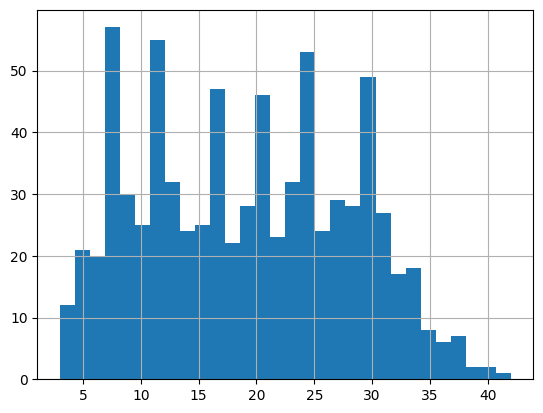

In [11]:
seq_len = [len(tokenizer_arabert.encode(i)) for i in train_texts]

pd.Series(seq_len).hist(bins = 30)

In [12]:
max_seq_len = 502
model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=3)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
train_encodings = tokenizer_arabert(train_texts.to_list(), truncation=True, padding=True, max_length=max_seq_len)
val_encodings = tokenizer_arabert(val_texts.to_list(), truncation=True, padding=True, max_length=max_seq_len)
test_encodings = tokenizer_arabert(test_texts.to_list(), truncation=True, padding=True, max_length=max_seq_len)

In [14]:
class preparerDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.to_list()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = preparerDataset(train_encodings, train_labels)
val_dataset = preparerDataset(val_encodings, val_labels)
test_dataset = preparerDataset(test_encodings, test_labels)

In [15]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# function to pass to out trainer in order to compute accuracy, f1 score, precision and recall
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [16]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [17]:
training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=5,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=32,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_strategy='epoch',
    eval_strategy='epoch',
    report_to="none"
    )

marbert = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,             # evaluation dataset
    compute_metrics=compute_metrics
)

marbert.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.077500,1.040223,0.527273,0.405576,0.469697,0.436192
2,1.005600,0.921527,0.642424,0.522556,0.756707,0.541601
3,0.776800,0.684191,0.709091,0.677932,0.701767,0.675656
4,0.530400,0.623864,0.739394,0.724710,0.717260,0.737787
5,0.299500,0.641680,0.733333,0.710288,0.737296,0.696215


TrainOutput(global_step=245, training_loss=0.7379684058987365, metrics={'train_runtime': 56.7659, 'train_samples_per_second': 67.822, 'train_steps_per_second': 4.316, 'total_flos': 83096561809800.0, 'train_loss': 0.7379684058987365, 'epoch': 5.0})

In [18]:
marbert.predict(test_dataset)

PredictionOutput(predictions=array([[-1.8074753 , -0.8719539 ,  2.4311624 ],
       [ 0.91973776,  1.517236  , -2.3693855 ],
       [-0.84999055,  2.507888  , -1.3312014 ],
       [-1.8231977 ,  0.51878816,  1.3528026 ],
       [-1.024881  ,  2.4284465 , -1.0745199 ],
       [-0.03456972,  2.2295506 , -1.8610466 ],
       [-1.8673999 , -0.26406243,  2.0678396 ],
       [-0.90866876,  2.3848522 , -1.1749136 ],
       [ 1.3949331 ,  0.9582282 , -2.3403492 ],
       [-0.85328466,  2.4338927 , -1.3439487 ],
       [ 2.0919971 , -0.7449795 , -1.6963469 ],
       [-0.7939754 ,  2.4188535 , -1.3090492 ],
       [-1.4002401 ,  2.2264452 , -0.51608384],
       [-1.0785321 ,  2.4293797 , -1.0713285 ],
       [-2.2071564 ,  0.55913275,  1.6793624 ],
       [-1.9097778 , -0.41566437,  2.1138291 ],
       [ 1.7593223 ,  0.5264701 , -2.3394613 ],
       [-1.1045746 ,  2.3954353 , -0.97311693],
       [-1.8257402 , -0.48192257,  2.23474   ],
       [ 1.1476494 ,  1.0571089 , -2.1989803 ],
       [-2.

In [19]:
predictions =marbert.predict(test_dataset)

Classification Report:
               precision    recall  f1-score   support

     abusive       0.81      0.71      0.76        31
        hate       0.71      0.74      0.73        66
      normal       0.77      0.78      0.77        68

    accuracy                           0.75       165
   macro avg       0.76      0.74      0.75       165
weighted avg       0.75      0.75      0.75       165



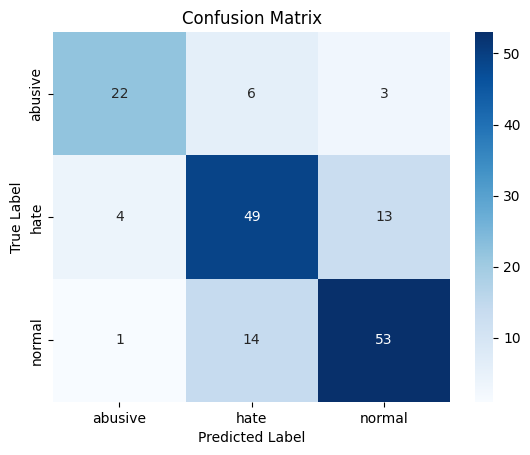

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["abusive", "hate", "normal"]))

conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["abusive", "hate", "normal"], yticklabels=["abusive", "hate", "normal"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# PRE_SPLITT AUGMENTATION

In [21]:
df = pd.read_excel(io.BytesIO(uploaded['Egyptian dataset.xlsx']))
df.head()

,commentaire,classe
0,مبروك و سامحونا لعجزنا التام. عقبال اللي جوه. ...,normal
1,كلنا بره ومش هنبطل نزايد على العجايز الي جابون...,hate
2,بدل ما انت قاعد بره كده تعالي ازرع الصحرا,normal
3,قذر اتفووو ماتيجى مصر وتورينا نفسك كدا ياجبان,hate
4,وهكذا رجال الشو اللي محرومين من عمل برنامج الغ...,hate


## Initial Data Exploration and Label Encoding



In [22]:
df['classe'].value_counts()

,count
classe,
normal,453
hate,444
abusive,203


In [23]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Label']=le.fit_transform(df['classe'])
df.head(6)

,commentaire,classe,Label
0,مبروك و سامحونا لعجزنا التام. عقبال اللي جوه. ...,normal,2
1,كلنا بره ومش هنبطل نزايد على العجايز الي جابون...,hate,1
2,بدل ما انت قاعد بره كده تعالي ازرع الصحرا,normal,2
3,قذر اتفووو ماتيجى مصر وتورينا نفسك كدا ياجبان,hate,1
4,وهكذا رجال الشو اللي محرومين من عمل برنامج الغ...,hate,1
5,أنت أزاي لبؤة كدة ؟,abusive,0


## Define Preprocessing Functions



## Apply Preprocessing to Full Dataset



In [24]:
df['commentaire'] = df['commentaire'].apply(lambda x: preprocess(x, do_farasa_tokenization=False))
df.head()

,commentaire,classe,Label
0,مبروك و سامحونا لعجزنا التام . عقبال اللي جوه ...,normal,2
1,كلنا بره ومش هنبطل نزايد على العجايز الي جابون...,hate,1
2,بدل ما انت قاعد بره كده تعالي ازرع الصحرا,normal,2
3,قذر اتفو ماتيجى مصر وتورينا نفسك كدا ياجبان,hate,1
4,وهكذا رجال الشو اللي محرومين من عمل برنامج الغ...,hate,1


## Stratified Train/Validation/Test Split




In [25]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(df['commentaire'], df['Label'], random_state=42, test_size=0.3, stratify=df['Label'])

val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, random_state=42, test_size=0.5, stratify=temp_labels)

print(f"Train texts length: {len(train_texts)}")
print(f"Validation texts length: {len(val_texts)}")
print(f"Test texts length: {len(test_texts)}")

Train texts length: 770
Validation texts length: 165
Test texts length: 165


## MARBERT Model and Tokenizer Setup


In [26]:
BERT_MODEL_NAME =  'UBC-NLP/MARBERTv2' #'UBC-NLP/MARBERTv2'
bert = AutoModel.from_pretrained(BERT_MODEL_NAME)

tokenizer_arabert = BertTokenizerFast.from_pretrained(BERT_MODEL_NAME)

## Setup Augmentation for Arabic Text




In [27]:
import nlpaug.augmenter.word.context_word_embs as aug

augmenter = aug.ContextualWordEmbsAug(model_path='UBC-NLP/MARBERTv2', action="insert") #bert-base-uncased
print("ContextualWordEmbsAug initialized")

The following layers were not sharded: bert.encoder.layer.*.attention.self.query.bias, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.attention.self.value.weight, cls.predictions.transform.LayerNorm.bias, cls.predictions.decoder.weight, cls.predictions.transform.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.output.LayerNorm.bias, cls.predictions.bias, cls.predictions.decoder.bias, bert.encoder.layer.*.output.dense.weight, bert.encoder.layer.*.attention.self.key.bias, cls.predictions.transform.LayerNorm.weight, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.attention.self.value.bias, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.intermediate.dense.weight, cls.predictions.transform.dense.bias, bert.embeddings.word_embeddings.weight, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.b

ContextualWordEmbsAug initialized


## Apply Augmentation to Training Set Only



In [28]:
from IPython.core.display import Javascript
from sklearn.utils import shuffle # Import shuffle
import numpy as np
from tqdm.auto import tqdm # Import tqdm, as it was also missing from the context in the previous run

def augmentMyData(df, augmenter, repetitions=1, sample0=200,sample1=200):
    for j in [0,1] :
      if j==0 :
        samples=sample0
      else :
        samples=sample1
      augmented_texts = []
      # select only the minority class samples
      spam_df = df[df['Label'] == j].reset_index(drop=True) # removes unecessary index column
      for i in tqdm(np.random.randint(0, len(spam_df), samples)):
          # generating 'n_samples' augmented texts
          for _ in range(repetitions):
              augmented_text = augmenter.augment(spam_df['commentaire'].iloc[i])
              augmented_texts.append(augmented_text)

      data = {
          'Label': j,
          'commentaire': augmented_texts
      }
      aug_df = pd.DataFrame(data)
      df = shuffle(pd.concat([df, aug_df]).reset_index(drop=True))
    return df

In [29]:
import pandas as pd

train_df_aug = pd.DataFrame({'commentaire': train_texts, 'Label': train_labels})

print("Initial training set class distribution:")
print(train_df_aug['Label'].value_counts())

Initial training set class distribution:
Label
2    317
1    311
0    142
Name: count, dtype: int64


In [30]:

# Manually set augmentation sizes to balance classes.
sample0 = 142 # Manual number of samples to augment for Label 0
sample1 = 6   # Manual number of samples to augment for Label 1

# Call the augmentation function
new_df = augmentMyData(train_df_aug, augmenter, repetitions=1, sample0=sample0, sample1=sample1)

  0%|          | 0/142 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

In [31]:

# Update train_texts and train_labels with augmented data
train_texts = new_df['commentaire']
train_labels = new_df['Label']
train_texts=train_texts.apply(preprocess)
print("\nAugmented training set class distribution:")
print(train_labels.value_counts())


Augmented training set class distribution:
Label
2    317
1    317
0    284
Name: count, dtype: int64


## Analyze Sequence Lengths of Augmented Training Data

<Axes: >

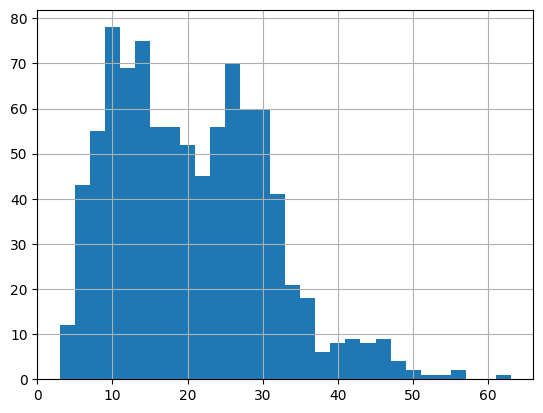

In [32]:
seq_len = [len(tokenizer_arabert.encode(item[0] if isinstance(item, list) else item)) for item in train_texts]
pd.Series(seq_len).hist(bins = 30)

## Initialize Classification Model



In [33]:
max_seq_len = 502
model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=3)

The following layers were not sharded: bert.encoder.layer.*.attention.self.query.bias, classifier.weight, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.attention.self.value.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.output.LayerNorm.bias, bert.pooler.dense.bias, bert.pooler.dense.weight, bert.encoder.layer.*.output.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.attention.self.value.bias, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.intermediate.dense.weight, classifier.bias, bert.embeddings.word_embeddings.weight, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.bias, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.en

In [34]:
train_texts_cleaned = train_texts.apply(lambda x: x[0] if isinstance(x, list) else x)
val_texts_cleaned = val_texts.apply(lambda x: x[0] if isinstance(x, list) else x)
test_texts_cleaned = test_texts.apply(lambda x: x[0] if isinstance(x, list) else x)

train_encodings = tokenizer_arabert(train_texts_cleaned.to_list(), truncation=True, padding=True, max_length=max_seq_len)
val_encodings = tokenizer_arabert(val_texts_cleaned.to_list(), truncation=True, padding=True, max_length=max_seq_len)
test_encodings = tokenizer_arabert(test_texts_cleaned.to_list(), truncation=True, padding=True, max_length=max_seq_len)

print("Datasets tokenized successfully.")

Datasets tokenized successfully.


In [35]:
class preparerDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.to_list()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = preparerDataset(train_encodings, train_labels)
val_dataset = preparerDataset(val_encodings, val_labels)
test_dataset = preparerDataset(test_encodings, test_labels)

print("PyTorch Dataset objects created successfully.")

PyTorch Dataset objects created successfully.


In [36]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# function to pass to out trainer in order to compute accuracy, f1 score, precision and recall
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("Compute metrics function defined successfully.")

Compute metrics function defined successfully.


In [37]:
import os
os.environ["WANDB_DISABLED"] = "true"

training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=5,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=32,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_strategy='epoch',
    eval_strategy='epoch',
    report_to="none"
    )

marbert = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,             # evaluation dataset
    compute_metrics=compute_metrics
)

marbert.train()

print("Model training initiated.")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.094400,1.062506,0.472727,0.364512,0.646094,0.391196
2,0.953200,0.850822,0.672727,0.608466,0.693743,0.602853
3,0.611000,0.650547,0.745455,0.719026,0.736179,0.711789
4,0.354100,0.853584,0.660606,0.650601,0.650715,0.679685
5,0.169600,0.867732,0.757576,0.746214,0.766580,0.734597


Model training initiated.


In [38]:
predictions = marbert.predict(test_dataset)
print("Predictions on the test dataset obtained successfully.")

Predictions on the test dataset obtained successfully.


Classification Report:
               precision    recall  f1-score   support

     abusive       0.71      0.81      0.76        31
        hate       0.62      0.71      0.66        66
      normal       0.80      0.63      0.70        68

    accuracy                           0.70       165
   macro avg       0.71      0.72      0.71       165
weighted avg       0.71      0.70      0.70       165



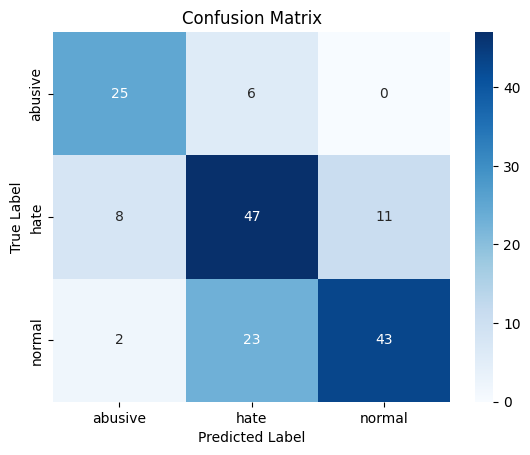

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["abusive", "hate", "normal"]))

conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["abusive", "hate", "normal"], yticklabels=["abusive", "hate", "normal"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# POST_SPLITT AUGMENTATION

In [40]:
import nlpaug.augmenter.word.context_word_embs as aug

In [41]:
augmenter = aug.ContextualWordEmbsAug(model_path='UBC-NLP/MARBERTv2', action="insert")   #bert-base-uncased


In [42]:
from sklearn.utils import shuffle
from sklearn.naive_bayes import GaussianNB
import numpy as np
from tqdm.auto import tqdm

In [43]:
from IPython.core.display import Javascript
def augmentMyData(df, augmenter, repetitions=1, sample0=200,sample1=200):
    for j in [0,1] :
      if j==0 :
        samples=sample0
      else :
        samples=sample1
      augmented_texts = []
      # select only the minority class samples
      spam_df = df[df['Label'] == j].reset_index(drop=True) # removes unecessary index column
      for i in tqdm(np.random.randint(0, len(spam_df), samples)):
          # generating 'n_samples' augmented texts
          for _ in range(repetitions):
              augmented_text = augmenter.augment(spam_df['commentaire'].iloc[i])
              augmented_texts.append(augmented_text)

      data = {
          'Label': j,
          'commentaire': augmented_texts
      }
      aug_df = pd.DataFrame(data)
      df = shuffle(pd.concat([df, aug_df]).reset_index(drop=True))
    return df

In [44]:
df['Label'].value_counts()

,count
Label,
2,453
1,444
0,203


In [45]:
new_df = augmentMyData(df, augmenter,sample0=200,sample1=10)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [46]:
new_df.to_excel('Egyptain dataset_balanced.xlsx')

In [47]:

new_df.head()

,commentaire,classe,Label
1059,أنت أكبر خائن بتحكيمك الديمقراطية الكافرة وإست...,hate,1
1192,"""انزل يا حمدين واوعدك حتكون شهيد وتقابل الشهدا...",hate,1
779,اي عرفتو ازاي الاخوان اللي قاللكو,normal,2
141,كلامك هابط .,hate,1
211,مش هيرد عليك يا عمر مش هيرد عليك . مش هيرد لأن...,normal,2


In [48]:
new_df['Label'].value_counts()

,count
Label,
1,454
2,453
0,403


In [49]:
df['Label'].value_counts()

,count
Label,
2,453
1,444
0,203


In [50]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(new_df['commentaire'], new_df['Label'], random_state=42,
                                                                    test_size=0.3, stratify=new_df['Label'])

train_texts=train_texts.apply(preprocess)
temp_texts=temp_texts.apply(preprocess)

val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, random_state=42,
                                                                test_size=0.5)

len(train_texts), len(val_texts), len(test_texts)

(917, 196, 197)

In [51]:
#covert splited dat to DataFrame
train_df = pd.DataFrame({"text": train_texts, "label": train_labels})
val_df   = pd.DataFrame({"text": val_texts,   "label": val_labels})
test_df  = pd.DataFrame({"text": test_texts,  "label": test_labels})

In [52]:
train_df.to_excel('Egyptian_balanced_Train.xlsx')

In [53]:
val_df.to_excel('Egyptian_blanced_Val.xlsx')

In [54]:
test_df.to_excel('Egyptian_balanced_Test.xlsx')

<Axes: >

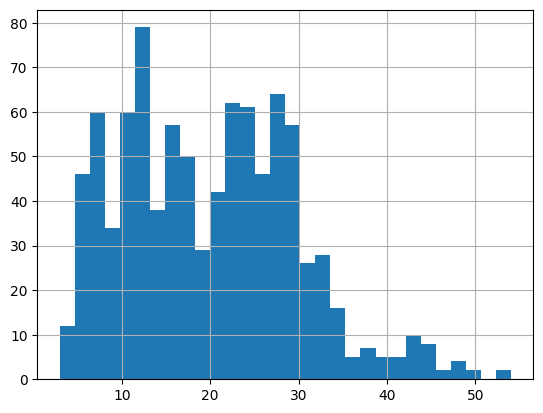

In [55]:
seq_len = [len(tokenizer_arabert.encode(i)) for i in train_texts]

pd.Series(seq_len).hist(bins = 30)

In [56]:
train_encodings = tokenizer_arabert(train_texts.to_list(), truncation=True, padding=True, max_length=max_seq_len)
val_encodings = tokenizer_arabert(val_texts.to_list(), truncation=True, padding=True, max_length=max_seq_len)
test_encodings = tokenizer_arabert(test_texts.to_list(), truncation=True, padding=True, max_length=max_seq_len)

In [57]:
train_dataset = preparerDataset(train_encodings, train_labels)
val_dataset = preparerDataset(val_encodings, val_labels)
test_dataset = preparerDataset(test_encodings, test_labels)

In [58]:
training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=5,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=32,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_strategy='epoch',
    eval_strategy='epoch',
    report_to="none"
    )

marbert = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,             # evaluation dataset
    compute_metrics=compute_metrics
)

marbert.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.311700,0.180444,0.959184,0.960460,0.959949,0.961246
2,0.253600,0.237881,0.933673,0.935406,0.935829,0.935219
3,0.187600,0.365286,0.918367,0.919334,0.918627,0.925210
4,0.110300,0.348437,0.933673,0.935188,0.934616,0.936005
5,0.063100,0.506893,0.897959,0.899197,0.898897,0.905619


TrainOutput(global_step=290, training_loss=0.1852788834736265, metrics={'train_runtime': 144.2733, 'train_samples_per_second': 31.78, 'train_steps_per_second': 2.01, 'total_flos': 127234865420460.0, 'train_loss': 0.1852788834736265, 'epoch': 5.0})

In [59]:
marbert.predict(test_dataset)

PredictionOutput(predictions=array([[-2.2663398 ,  4.6498632 , -2.5919821 ],
       [ 4.412404  , -2.6816206 , -1.5854377 ],
       [ 4.409144  , -2.581713  , -1.6967206 ],
       [ 4.377443  , -2.720227  , -1.4827611 ],
       [-1.6735644 ,  4.514312  , -3.0341566 ],
       [-2.3618686 , -2.2614076 ,  4.6845293 ],
       [ 4.360383  , -2.6901672 , -1.4750539 ],
       [ 4.4199905 , -2.6818192 , -1.6212124 ],
       [ 3.99014   , -1.6725186 , -2.185436  ],
       [ 3.6202054 , -1.6042045 , -2.0995193 ],
       [ 4.4161    , -2.6896765 , -1.582968  ],
       [-2.4886682 ,  4.6402183 , -2.3730364 ],
       [-2.3940234 , -2.0327852 ,  4.5296926 ],
       [ 0.43525857,  3.0717063 , -3.7129698 ],
       [ 4.3869686 , -2.7461712 , -1.4534771 ],
       [-2.3606777 ,  4.6752357 , -2.510758  ],
       [-2.413402  ,  4.637629  , -2.4122934 ],
       [-2.2784417 , -2.3550355 ,  4.6107492 ],
       [-2.6144605 ,  4.583386  , -2.2228405 ],
       [-2.4799938 , -2.074697  ,  4.4286394 ],
       [ 4.

Classification Report:
               precision    recall  f1-score   support

     abusive       0.89      0.95      0.92        62
        hate       0.89      0.87      0.88        62
      normal       0.97      0.93      0.95        73

    accuracy                           0.92       197
   macro avg       0.92      0.92      0.92       197
weighted avg       0.92      0.92      0.92       197



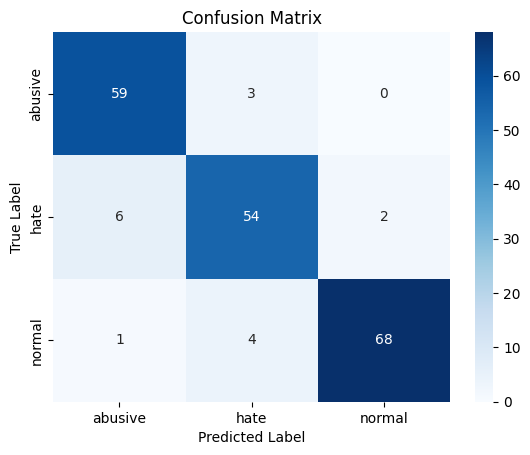

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

predictions = marbert.predict(test_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["abusive", "hate", "normal"]))

conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["abusive", "hate", "normal"], yticklabels=["abusive", "hate", "normal"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()